# DS 121 Fall 2025 - Homework 3

## Instructions:

The purpose of this file is to test your code. ***Fill in the blanks on Gradescope in order to receive credit!!!***

## Question 1 (7 points)

**Complete the code below.**

## Part a

Create a synthetic dataset consisting of 120 samples, each represented as a 25-dimensional feature vector. The data is organized into 4 distinct clusters, with cluster centers randomly distributed within a box ranging from -8.0 to 8.0 in each dimension.

In [2]:
# Step 1: Generate synthetic data
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=120, centers=4, n_features=25,
                  center_box=(-8.0, 8.0), random_state=42)

## Part b

Visualize the data matrix and its pairwise Euclidean distances.

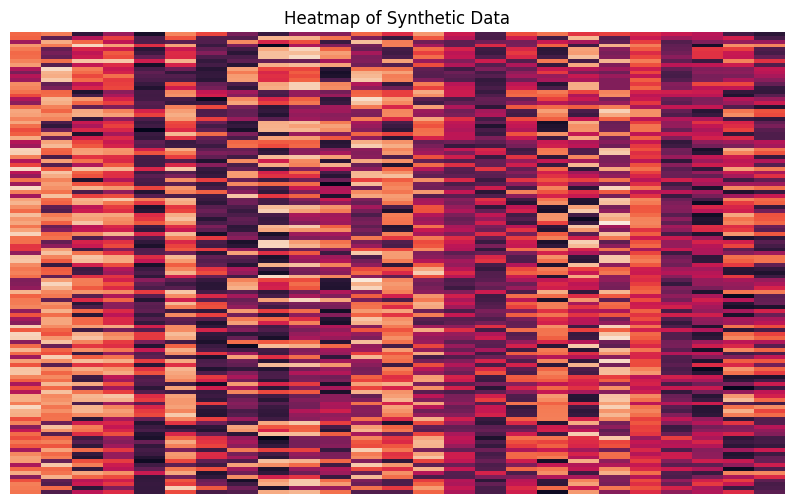

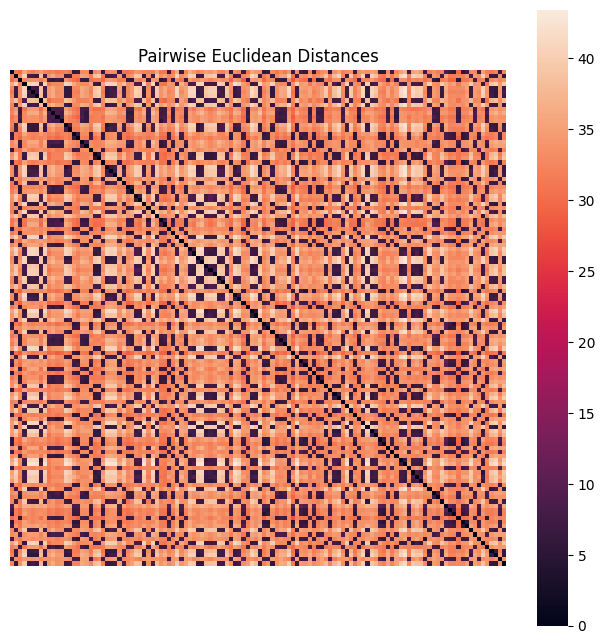

In [9]:
# Step 2: Visualize the data 

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.heatmap(X, xticklabels=False, yticklabels=False, linewidths=0, cbar=False)
plt.title("Heatmap of Synthetic Data")
plt.show()

# Step 3: Compute pairwise Euclidean distances
from sklearn.metrics import euclidean_distances
dists = euclidean_distances(X)

# Step 4: Visualize the distance matrix
plt.figure(figsize=(8, 8))
sns.heatmap(dists, xticklabels=False, yticklabels=False, linewidths=0, square=True)
plt.title("Pairwise Euclidean Distances")
plt.show()

Apply Multidimensional Scaling (MDS) to project the high-dimensional data into 2D.

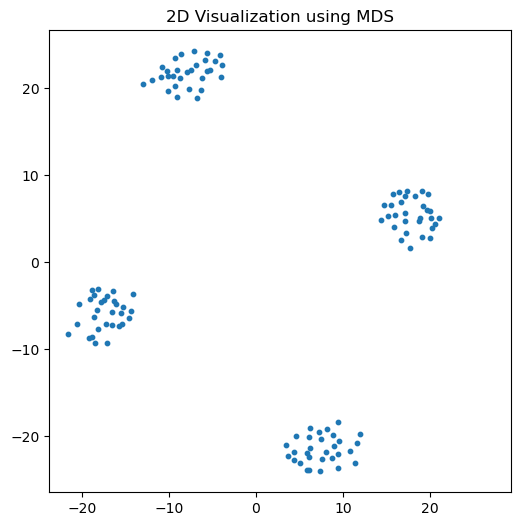

In [ ]:
# Step 5: Apply MDS to reduce to 2D
from sklearn.manifold import MDS
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
pos = mds.fit_transform(dists)

plt.figure(figsize=(6, 6))
plt.scatter(pos[:, 0], pos[:, 1], s=10)
plt.title("2D Visualization using MDS")
plt.axis('square')
plt.show()

## Part c

Apply k-means with k-means++ initialization and 100 runs to partition the data into 4 clusters, optimizing centroid placement and minimizing clustering error.

In [16]:
# Step 6: Perform k-means clustering
from sklearn.cluster import KMeans
import numpy as np
kmeans = KMeans(init='k-means++', n_clusters=4, n_init=100, random_state=42)
labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_
error = kmeans.inertia_

print(f'Total clustering error: {error:.1f}')
print('Cluster centroids:\n', np.round(centroids, 2))

Total clustering error: 2849.7
Cluster centroids:
 [[ 7.59  4.5   6.94  6.22  1.61  6.76 -6.53 -4.82 -7.1  -2.69 -1.78 -3.59
   5.14 -2.04 -3.57  0.45 -5.76  4.75 -6.89  7.97  4.34 -4.77 -7.8   5.07
   3.5 ]
 [ 4.51 -4.91  0.36  1.81 -7.35  1.68 -4.9  -6.77  7.4   7.57  4.97 -3.09
  -6.44  2.99 -0.81 -5.71  0.19 -7.58  6.9  -3.62  2.58 -3.11  0.35  0.97
  -5.27]
 [-1.99  7.38  3.98  1.52 -5.58 -5.66 -7.24  5.72  1.86  3.32 -7.55  7.57
   5.48 -4.55 -5.27 -4.79 -3.24  0.28 -1.03 -3.24  1.39 -5.77 -3.11 -2.11
  -0.8 ]
 [ 4.03  4.41 -6.67 -2.15 -6.17  5.6   1.92 -2.73 -6.87 -3.13 -2.79  3.65
   1.92  6.36 -0.09 -6.3   3.15  4.1   0.96  4.28  0.06 -0.22 -0.97 -7.43
  -6.38]]


Reorder the data and distance matrices based on cluster labels and visualize the resulting dataset and its pairwise distances.

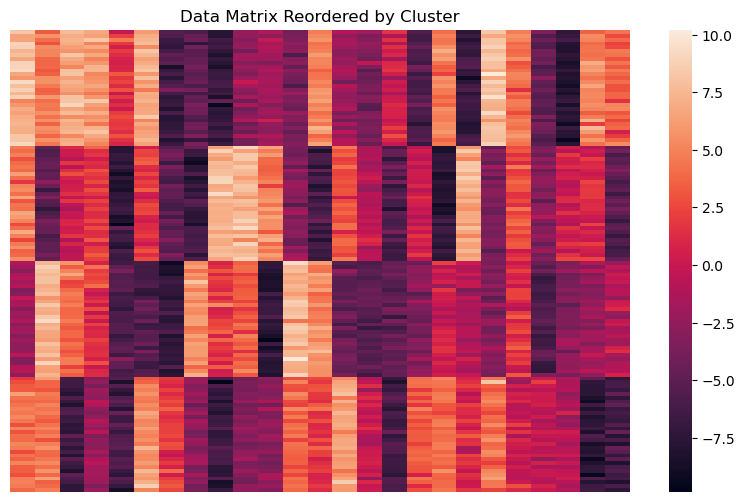

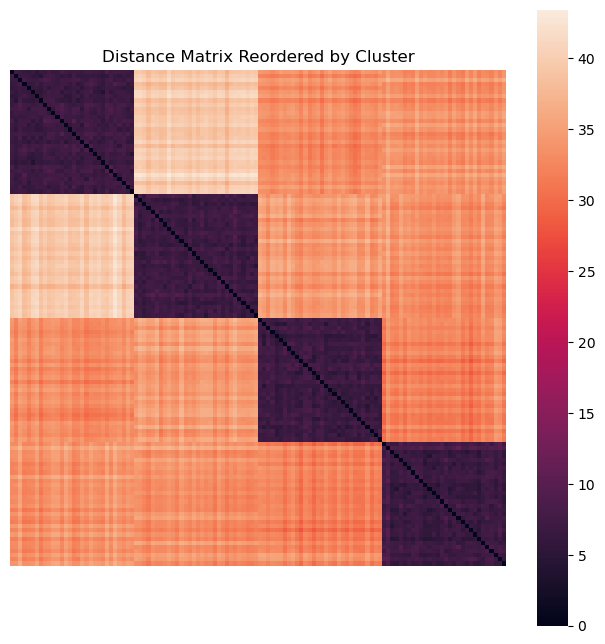

In [5]:
# Step 7: Reorder data by cluster labels and visualize
idx = np.argsort(labels)
rX = X[idx, :]
plt.figure(figsize=(10, 6))
sns.heatmap(rX, xticklabels=False, yticklabels=False, linewidths=0)
plt.title("Data Matrix Reordered by Cluster")
plt.show()

# Step 8: Reorder distance matrix and visualize
reordered_dists = dists[idx, :][:, idx]
plt.figure(figsize=(8, 8))
sns.heatmap(reordered_dists, xticklabels=False, yticklabels=False, linewidths=0, square=True)
plt.title("Distance Matrix Reordered by Cluster")
plt.show()